In [43]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [9]:
os.chdir("/Users/kaiping/Desktop/olist_project/data/interim") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data/interim'

### 1. 讀取資料

In [10]:
file_path = Path("/Users/kaiping/Desktop/olist_project/data/interim/orders_delivered_base.csv")

orders_delivered_base = pd.read_csv(file_path)

print("原始資料筆數：", orders_delivered_base.shape[0])
print("原始欄位數：", orders_delivered_base.shape[1])
orders_delivered_base.head()

原始資料筆數： 96478
原始欄位數： 10


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2018-02-01


In [11]:
# =========================
# 2. 日期欄位轉型
# =========================
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders_delivered_base[col] = pd.to_datetime(orders_delivered_base[col], errors="coerce")

orders_delivered_base[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [71]:
# 3. 設定分析截止日
data_end = pd.Timestamp("2018-08-29 15:00:00")
analysis_end = pd.Timestamp("2018-05-31 15:00:00")

orders_delivered_base = orders_delivered_base.loc[
    orders_delivered_base["order_purchase_timestamp"] <= analysis_end
].copy()

print("截斷後資料筆數：", orders_delivered_base.shape[0])
print("截斷後客戶唯一值數量：", orders_delivered_base["customer_unique_id"].nunique())
print("下單時間範圍：")
print("min =", orders_delivered_base["order_purchase_timestamp"].min())
print("max =", orders_delivered_base["order_purchase_timestamp"].max())

截斷後資料筆數： 77799
截斷後客戶唯一值數量： 75320
下單時間範圍：
min = 2016-09-15 12:16:00
max = 2018-05-31 14:51:00


In [14]:
orders_delivered_base

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,2017-10-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2018-02-01
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,delivered,2017-07-09 21:57:00,2017-07-09 22:10:00,2017-07-11 14:58:00,2017-07-26 10:57:00,2017-08-01,2017-07-01
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,932afa1e708222e5821dac9cd5db4cae,delivered,2017-05-16 13:10:00,2017-05-16 13:22:00,2017-05-22 10:07:00,2017-05-26 12:55:00,2017-06-07,2017-05-01
...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,6359f309b166b0196dbf7ad2ac62bb5a,delivered,2017-03-09 09:54:00,2017-03-09 09:54:00,2017-03-10 11:18:00,2017-03-17 15:08:00,2017-03-28,2017-03-01
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,da62f9e57a76d978d02ab5362c509660,delivered,2018-02-06 12:58:00,2018-02-06 13:10:00,2018-02-07 23:22:00,2018-02-28 17:37:00,2018-03-02,2018-02-01
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,737520a9aad80b3fbbdad19b66b37b30,delivered,2017-08-27 14:46:00,2017-08-27 15:04:00,2017-08-28 20:52:00,2017-09-21 11:24:00,2017-09-27,2017-08-01
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,delivered,2018-01-08 21:28:00,2018-01-08 21:36:00,2018-01-12 15:35:00,2018-01-25 23:32:00,2018-02-15,2018-01-01


### 2. 回購基礎分析

In [18]:
# 2.1 顧客購買次數分布
customer_order_cnt = (
    orders_delivered_base
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="order_cnt")
)

customer_order_cnt["is_repeat_customer"] = customer_order_cnt["order_cnt"] >= 2

summary_purchase_freq = pd.DataFrame({
    "total_customers": [customer_order_cnt["customer_unique_id"].nunique()],
    "one_time_customers": [(customer_order_cnt["order_cnt"] == 1).sum()],
    "repeat_customers": [(customer_order_cnt["order_cnt"] >= 2).sum()]
})

summary_purchase_freq["one_time_rate"] = (
    summary_purchase_freq["one_time_customers"] / summary_purchase_freq["total_customers"]
)
summary_purchase_freq["repeat_rate"] = (
    summary_purchase_freq["repeat_customers"] / summary_purchase_freq["total_customers"]
)

summary_purchase_freq

,total_customers,one_time_customers,repeat_customers,one_time_rate,repeat_rate
0,75320,73092,2228,0.97042,0.02958


In [19]:
# 2.2 每位顧客的回購次數分布

# 每位顧客的總購買次數 (客人同時下單兩筆訂單也算進去)
customer_order_cnt = (
    orders_delivered_base
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

purchase_count_dist = (
    customer_order_cnt["total_orders"]
    .value_counts()
    .sort_index()
    .reset_index()
)

purchase_count_dist.columns = ["total_orders", "customer_count"]
purchase_count_dist["customer_rate"] = (
    purchase_count_dist["customer_count"] / purchase_count_dist["customer_count"].sum()
)

purchase_count_dist.head(10)

,total_orders,customer_count,customer_rate
0,1,73092,0.970420
1,2,2043,0.027124
2,3,152,0.002018
3,4,17,0.000226
4,5,7,0.000093
5,6,6,0.000080
6,7,1,0.000013
7,9,1,0.000013
8,10,1,0.000013


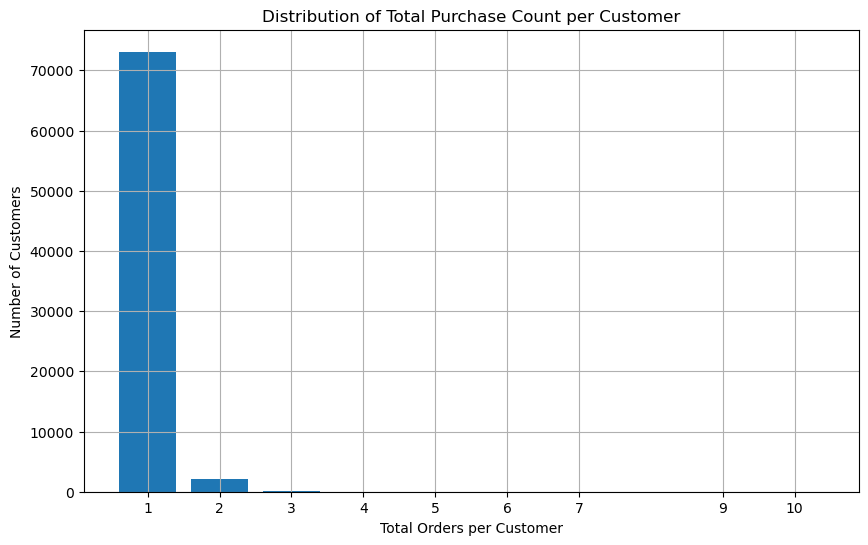

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(
    purchase_count_dist["total_orders"],
    purchase_count_dist["customer_count"]
)

plt.xlabel("Total Orders per Customer")
plt.ylabel("Number of Customers")
plt.title("Distribution of Total Purchase Count per Customer")
plt.xticks(purchase_count_dist["total_orders"])
plt.grid(True)
plt.show()

資料顯示 97% 顧客僅購買一次，代表平台高度依賴新客、留存結構薄弱

In [24]:
# 2.3 每位回購顧客購買次數分析(有兩筆order就算回購)
repeat_purchase_dist = purchase_count_dist.loc[
    purchase_count_dist["total_orders"] >= 2
].copy()

In [25]:
repeat_purchase_dist["customer_rate"] = (
    repeat_purchase_dist["customer_count"] /
    repeat_purchase_dist["customer_count"].sum()
)

In [26]:
repeat_purchase_dist

,total_orders,customer_count,customer_rate
1,2,2043,0.916966
2,3,152,0.068223
3,4,17,0.007630
4,5,7,0.003142
5,6,6,0.002693
6,7,1,0.000449
7,9,1,0.000449
8,10,1,0.000449


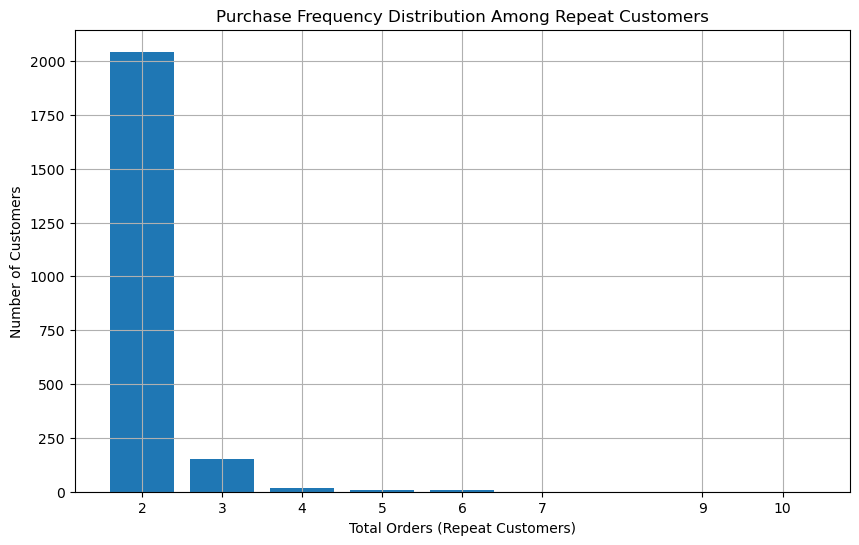

In [29]:
plt.figure(figsize=(10,6))

plt.bar(
    repeat_purchase_dist["total_orders"],
    repeat_purchase_dist["customer_count"]
)

plt.xlabel("Total Orders (Repeat Customers)")
plt.ylabel("Number of Customers")
plt.title("Purchase Frequency Distribution Among Repeat Customers")

plt.xticks(repeat_purchase_dist["total_orders"])
plt.grid(True)
plt.show()

In [72]:
# 2.4 每位顧客平均 / 中位數購買次數
mean_orders = (
    (purchase_count_dist["total_orders"] * purchase_count_dist["customer_count"]).sum()
    / purchase_count_dist["customer_count"].sum()
)

# 展開成顧客層級後取中位數
median_orders = np.repeat(
    purchase_count_dist["total_orders"],
    purchase_count_dist["customer_count"]
).median()

print("平均購買次數:", round(mean_orders, 4))
print("購買次數中位數:", median_orders)

平均購買次數: 1.0329
購買次數中位數: 1.0


In [31]:
# 2.5 購買次數中位數與分位數

dist = purchase_count_dist.copy()

# 依購買次數排序
dist = dist.sort_values("total_orders")

# 累積顧客數
dist["cum_customer"] = dist["customer_count"].cumsum()

# 累積比例
dist["cum_rate"] = dist["cum_customer"] / dist["customer_count"].sum()

dist

,total_orders,customer_count,customer_rate,cum_customer,cum_rate
0,1,73092,0.970420,73092,0.970420
1,2,2043,0.027124,75135,0.997544
2,3,152,0.002018,75287,0.999562
3,4,17,0.000226,75304,0.999788
4,5,7,0.000093,75311,0.999881
5,6,6,0.000080,75317,0.999960
6,7,1,0.000013,75318,0.999973
7,9,1,0.000013,75319,0.999987
8,10,1,0.000013,75320,1.000000


In [35]:
quantiles = [0.25,0.5,0.75,0.9,0.95,0.99]

quantile_results = {}

for q in quantiles:
    value = dist.loc[dist["cum_rate"] >= q, "total_orders"].iloc[0]
    quantile_results[q] = value

quantile_results

{0.25: np.int64(1),
 0.5: np.int64(1),
 0.75: np.int64(1),
 0.9: np.int64(1),
 0.95: np.int64(1),
 0.99: np.int64(2)}

In [33]:
summary = pd.DataFrame({
    "metric":[
        "mean",
        "median",
        "p25",
        "p50",
        "p75",
        "p90",
        "p95",
        "p99"
    ],
    "value":[
        mean_orders,
        quantile_results[0.5],
        quantile_results[0.25],
        quantile_results[0.5],
        quantile_results[0.75],
        quantile_results[0.9],
        quantile_results[0.95],
        quantile_results[0.99],
    ]
})

summary

,metric,value
0,mean,1.032913
1,median,1.000000
2,p25,1.000000
3,p50,1.000000
4,p75,1.000000
5,p90,1.000000
6,p95,1.000000
7,p99,2.000000


### 3. 回購間隔分析

In [38]:

#每位顧客首次第二次回購間隔分佈 (兩筆order就算回購)
df = orders_delivered_base.copy()



# 依顧客、時間排序
df = df.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).reset_index(drop=True)

# 對每位顧客編購買序號
df["purchase_seq"] = df.groupby("customer_unique_id").cumcount() + 1

# 只取前兩次購買
first_second = df[df["purchase_seq"].isin([1, 2])].copy()

# 轉成每位顧客一列
first_second_wide = (
    first_second
    .pivot_table(
        index="customer_unique_id",
        columns="purchase_seq",
        values="order_purchase_timestamp",
        aggfunc="first"
    )
    .rename(columns={1: "first_purchase_ts", 2: "second_purchase_ts"})
    .reset_index()
)

# 只保留真的有第二次購買的顧客
first_second_wide = first_second_wide.dropna(subset=["first_purchase_ts", "second_purchase_ts"]).copy()

# 計算回購間隔
first_second_wide["repurchase_gap_days"] = (
    first_second_wide["second_purchase_ts"] - first_second_wide["first_purchase_ts"]
).dt.total_seconds() / 86400

# 如果你想看整數天
first_second_wide["repurchase_gap_days_int"] = first_second_wide["repurchase_gap_days"].round(0).astype(int)

# 檢查結果
first_second_gap = first_second_wide[[
    "customer_unique_id",
    "first_purchase_ts",
    "second_purchase_ts",
    "repurchase_gap_days",
    "repurchase_gap_days_int"
]]

first_second_gap.head()


purchase_seq,customer_unique_id,first_purchase_ts,second_purchase_ts,repurchase_gap_days,repurchase_gap_days_int
81,004288347e5e88a27ded2bb23747066c,2017-07-27 14:13:00,2018-01-14 07:36:00,170.724306,171
240,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:00,2017-03-21 19:25:00,0.000000,0
322,011575986092c30523ecb71ff10cb473,2018-02-17 15:54:00,2018-04-18 21:58:00,60.252778,60
335,011b4adcd54683b480c4d841250a987f,2017-08-22 12:51:00,2018-02-15 11:40:00,176.950694,177
344,012452d40dafae4df401bced74cdb490,2017-06-18 22:46:00,2018-05-14 12:12:00,329.559722,330


In [39]:
print("有第二次購買的顧客數：", len(first_second_gap))

有第二次購買的顧客數： 2228


In [40]:
gap_desc = first_second_gap["repurchase_gap_days"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

print(gap_desc)

count    2228.000000
mean       66.049852
std        94.314681
min         0.000000
25%         0.000000
50%        19.741667
75%       102.971701
90%       207.078889
95%       279.970312
99%       375.471944
max       580.693750
Name: repurchase_gap_days, dtype: float64


In [41]:
gap_summary = {
    "customer_with_2plus_orders": len(first_second_gap),
    "mean_days": first_second_gap["repurchase_gap_days"].mean(),
    "median_days": first_second_gap["repurchase_gap_days"].median(),
    "p25": first_second_gap["repurchase_gap_days"].quantile(0.25),
    "p50": first_second_gap["repurchase_gap_days"].quantile(0.50),
    "p75": first_second_gap["repurchase_gap_days"].quantile(0.75),
    "p90": first_second_gap["repurchase_gap_days"].quantile(0.90),
    "p95": first_second_gap["repurchase_gap_days"].quantile(0.95),
    "p99": first_second_gap["repurchase_gap_days"].quantile(0.99),
}

for k, v in gap_summary.items():
    print(f"{k}: {v:.2f}" if isinstance(v, (int, float, np.floating)) else f"{k}: {v}")

customer_with_2plus_orders: 2228.00
mean_days: 66.05
median_days: 19.74
p25: 0.00
p50: 19.74
p75: 102.97
p90: 207.08
p95: 279.97
p99: 375.47


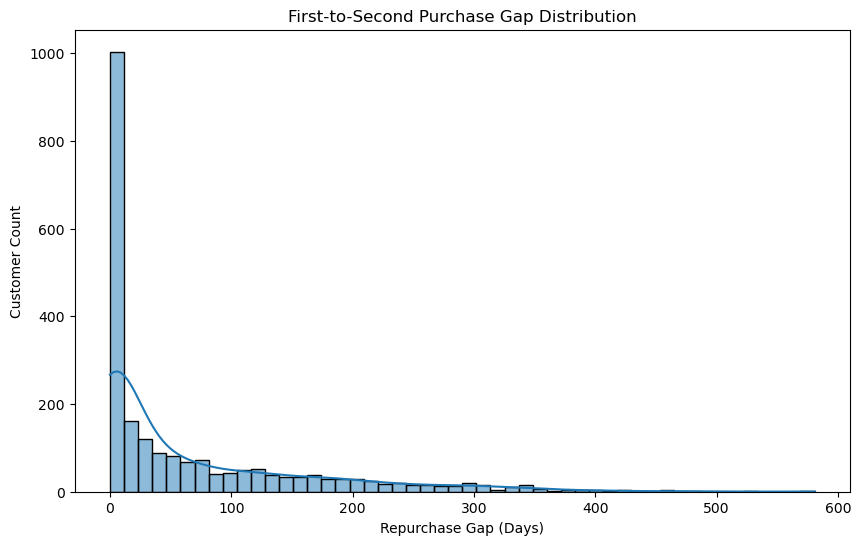

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=first_second_gap,
    x="repurchase_gap_days",
    bins=50,
    kde=True
)
plt.title("First-to-Second Purchase Gap Distribution")
plt.xlabel("Repurchase Gap (Days)")
plt.ylabel("Customer Count")
plt.show()

25 分位數為 0 天，顯示有相當比例顧客的前兩次購買發生於同一天，  
可能反映拆單或短時間連續下單現象，因此後續在定義「回購」與建立流失規則時，  
需進一步檢查同日多單是否應視為真正回購事件

In [46]:
gap_zero_mask = first_second_gap["repurchase_gap_days"] == 0
gap_zero_count = gap_zero_mask.sum()
gap_zero_rate = gap_zero_count / len(first_second_gap)

print("gap=0 人數:", gap_zero_count)
print("gap=0 佔比:", round(gap_zero_rate, 4))

gap=0 人數: 625
gap=0 佔比: 0.2805


In [54]:
# 驗證二次回購是否被假回購影響

# 1. gap=0比例
gap_zero_rate = (first_second_gap["repurchase_gap_days"] == 0).mean()


# 2. 同日期 / 同時間
tmp = first_second_gap.copy()
tmp["same_timestamp"] = tmp["first_purchase_ts"] == tmp["second_purchase_ts"]
tmp["same_date"] = tmp["first_purchase_ts"].dt.date == tmp["second_purchase_ts"].dt.date

zero_cases = tmp[tmp["repurchase_gap_days"] == 0]



# 3. 24小時內比例
tmp["repurchase_gap_hours"] = (
    tmp["second_purchase_ts"] - tmp["first_purchase_ts"]
).dt.total_seconds() / 3600



In [55]:
total_cnt = len(tmp)
gap0_cnt = (tmp["repurchase_gap_days"] == 0).sum()
within_1h_cnt = (tmp["repurchase_gap_hours"] <= 1).sum()
within_24h_cnt = (tmp["repurchase_gap_hours"] <= 24).sum()

print("全部樣本數:", total_cnt)
print("gap=0人數:", gap0_cnt)
print("gap=0比例:", round(gap_zero_rate, 4))
print("1小時內人數:", within_1h_cnt)
print("24小時內人數:", within_24h_cnt)

全部樣本數: 2228
gap=0人數: 625
gap=0比例: 0.2805
1小時內人數: 738
24小時內人數: 783


In [57]:
# A. 寬鬆定義
repurchase_loose = first_second_gap.copy()

# B. 主定義：排除 same timestamp
repurchase_main = first_second_gap[
    first_second_gap["first_purchase_ts"] != first_second_gap["second_purchase_ts"]
].copy()

# C. 嚴格定義：超過 24 小時
repurchase_strict_24h = first_second_gap[
    first_second_gap["repurchase_gap_days"] > 1
].copy()

print("寬鬆版樣本數:", len(repurchase_loose))
print("主定義樣本數:", len(repurchase_main))
print("嚴格24h樣本數:", len(repurchase_strict_24h))

寬鬆版樣本數: 2228
主定義樣本數: 1603
嚴格24h樣本數: 1445


In [51]:
# 重新定義回購(下單時間不同才能算) 再計算一次首次和第二次購買時間差分佈
gap_excl_same_ts = first_second_gap[
    first_second_gap["first_purchase_ts"] != first_second_gap["second_purchase_ts"]
].copy()

gap_excl_same_ts["repurchase_gap_days"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

count    1603.000000
mean       91.802290
std       100.000116
min         0.000694
25%        13.000000
50%        53.525694
75%       144.751736
90%       241.483611
95%       300.970347
99%       395.657306
max       580.693750
Name: repurchase_gap_days, dtype: float64

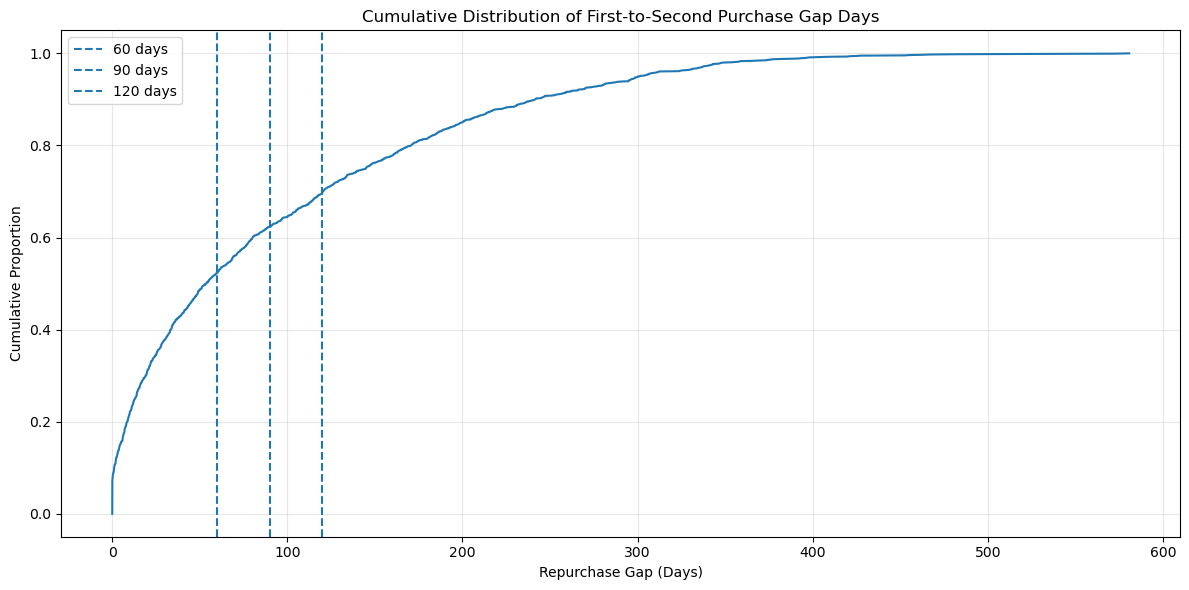

In [85]:

gap_excl_same_ts = first_second_gap[
    first_second_gap["first_purchase_ts"] != first_second_gap["second_purchase_ts"]
].copy()

x = np.sort(gap_excl_same_ts["repurchase_gap_days"].values)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.axvline(60, linestyle="--", label="60 days")
plt.axvline(90, linestyle="--", label="90 days")
plt.axvline(120, linestyle="--", label="120 days")

plt.title("Cumulative Distribution of First-to-Second Purchase Gap Days")
plt.xlabel("Repurchase Gap (Days)")
plt.ylabel("Cumulative Proportion")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
# 所有訂單間隔分佈 (全體顧客的整體回購節奏)

df = orders_delivered_base.copy()


# 保留必要欄位
df = df[["order_id", "customer_unique_id", "order_purchase_timestamp"]].dropna().copy()

# 依顧客、時間、order_id 排序
df = df.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).reset_index(drop=True)

#  找前一筆訂單時間
df["prev_purchase_timestamp"] = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"].shift(1)
)

#  只保留有前一筆訂單者
intervals = df[df["prev_purchase_timestamp"].notna()].copy()

# 排除相同 timestamp（你定義為不算回購節奏）
intervals = intervals[
    intervals["order_purchase_timestamp"] != intervals["prev_purchase_timestamp"]
].copy()

# 7. 計算間隔
intervals["gap_timedelta"] = (
    intervals["order_purchase_timestamp"] - intervals["prev_purchase_timestamp"]
)
intervals["gap_days"] = intervals["gap_timedelta"].dt.total_seconds() / 86400
intervals["gap_hours"] = intervals["gap_timedelta"].dt.total_seconds() / 3600

# 8. 基本統計
print("有效訂單間隔筆數:", len(intervals))
print("\n=== gap_days 摘要統計 ===")
print(
    intervals["gap_days"].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

# 9. 累積比例
for d in [1, 7, 30, 60, 90, 180,360]:
    rate = (intervals["gap_days"] <= d).mean()
    print(f"{d}天內回購比例: {rate:.2%}")

有效訂單間隔筆數: 1818

=== gap_days 摘要統計 ===
count    1818.000000
mean       87.993253
std        97.356475
min         0.000694
25%        12.097917
50%        50.110069
75%       135.182118
90%       234.577708
95%       296.935937
99%       390.560021
max       580.693750
Name: gap_days, dtype: float64
1天內回購比例: 10.29%
7天內回購比例: 18.48%
30天內回購比例: 38.45%
60天內回購比例: 54.07%
90天內回購比例: 64.08%
180天內回購比例: 82.84%
360天內回購比例: 98.46%


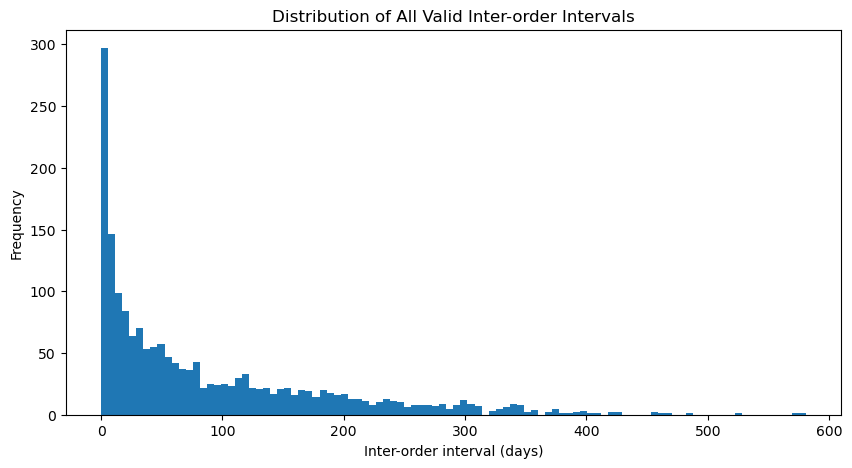

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(intervals["gap_days"], bins=100)
plt.xlabel("Inter-order interval (days)")
plt.ylabel("Frequency")
plt.title("Distribution of All Valid Inter-order Intervals")
plt.show()

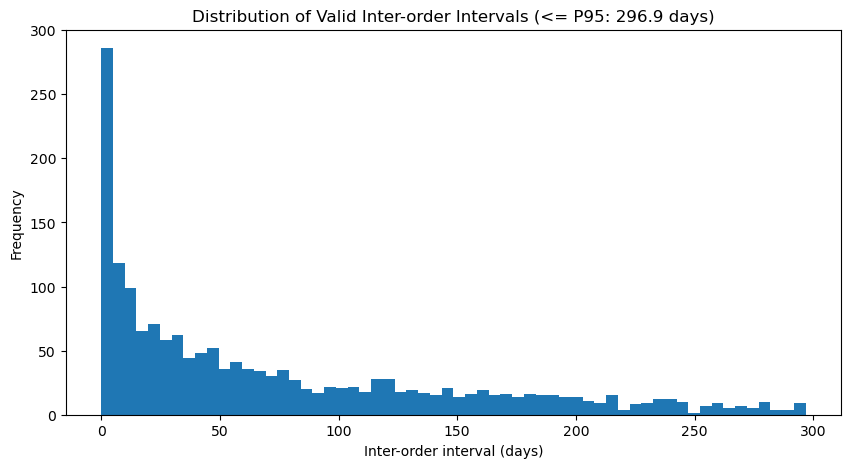

In [62]:
p95 = intervals["gap_days"].quantile(0.95)

plt.figure(figsize=(10, 5))
plt.hist(intervals.loc[intervals["gap_days"] <= p95, "gap_days"], bins=60)
plt.xlabel("Inter-order interval (days)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Valid Inter-order Intervals (<= P95: {p95:.1f} days)")
plt.show()

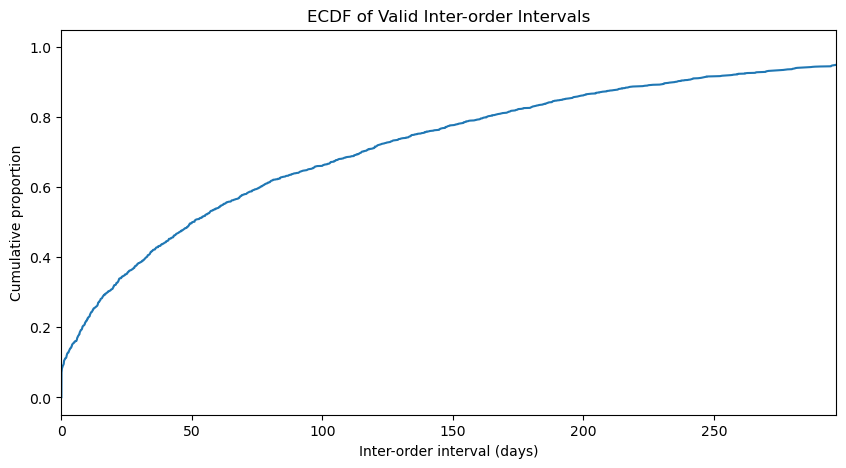

In [63]:
x = np.sort(intervals["gap_days"].values)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.xlim(0, p95)
plt.xlabel("Inter-order interval (days)")
plt.ylabel("Cumulative proportion")
plt.title("ECDF of Valid Inter-order Intervals")
plt.show()

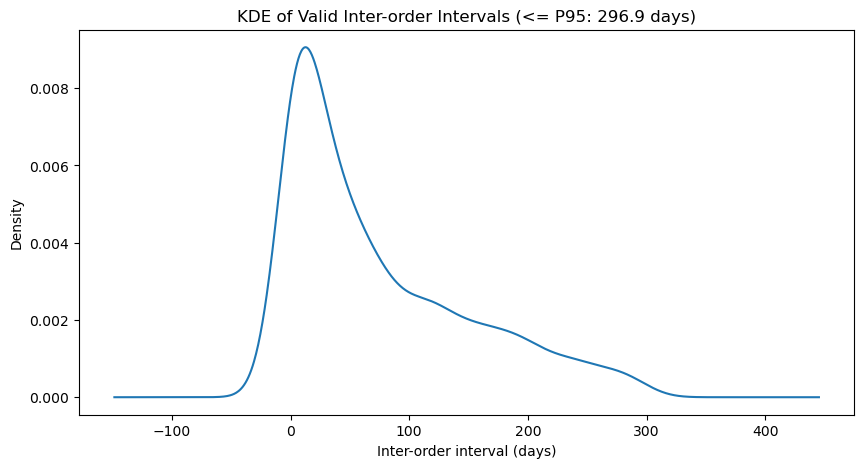

In [64]:
plt.figure(figsize=(10, 5))
intervals.loc[intervals["gap_days"] <= p95, "gap_days"].plot(kind="kde")
plt.xlabel("Inter-order interval (days)")
plt.title(f"KDE of Valid Inter-order Intervals (<= P95: {p95:.1f} days)")
plt.show()

In [65]:
interval_summary = pd.DataFrame({
    "metric": [
        "n_intervals",
        "mean_days",
        "median_days",
        "p25_days",
        "p75_days",
        "p90_days",
        "p95_days",
        "p99_days",
        "within_1_day_rate",
        "within_7_days_rate",
        "within_30_days_rate",
        "within_60_days_rate",
        "within_90_days_rate",
        "within_180_days_rate",
    ],
    "value": [
        len(intervals),
        intervals["gap_days"].mean(),
        intervals["gap_days"].median(),
        intervals["gap_days"].quantile(0.25),
        intervals["gap_days"].quantile(0.75),
        intervals["gap_days"].quantile(0.90),
        intervals["gap_days"].quantile(0.95),
        intervals["gap_days"].quantile(0.99),
        (intervals["gap_days"] <= 1).mean(),
        (intervals["gap_days"] <= 7).mean(),
        (intervals["gap_days"] <= 30).mean(),
        (intervals["gap_days"] <= 60).mean(),
        (intervals["gap_days"] <= 90).mean(),
        (intervals["gap_days"] <= 180).mean(),
    ]
})

interval_summary

,metric,value
0,n_intervals,1818.000000
1,mean_days,87.993253
2,median_days,50.110069
3,p25_days,12.097917
4,p75_days,135.182118
5,p90_days,234.577708
6,p95_days,296.935937
7,p99_days,390.560021
8,within_1_day_rate,0.102860
9,within_7_days_rate,0.184818


In [66]:
# 每位顧客的平均回購間隔分佈 (顧客的一個代表值來畫出分佈) 

df = orders_delivered_base.copy()


# 保留必要欄位
df = df[["order_id", "customer_unique_id", "order_purchase_timestamp"]].dropna().copy()

# 排序
df = df.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).reset_index(drop=True)

# 前一筆訂單時間
df["prev_purchase_timestamp"] = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"].shift(1)
)

# 只保留有前一筆訂單者
intervals = df[df["prev_purchase_timestamp"].notna()].copy()

# 排除相同 timestamp
intervals = intervals[
    intervals["order_purchase_timestamp"] != intervals["prev_purchase_timestamp"]
].copy()

# 計算 gap
intervals["gap_timedelta"] = (
    intervals["order_purchase_timestamp"] - intervals["prev_purchase_timestamp"]
)
intervals["gap_days"] = intervals["gap_timedelta"].dt.total_seconds() / 86400

# 每位顧客的平均回購間隔
customer_avg_gap = (
    intervals.groupby("customer_unique_id", as_index=False)
    .agg(
        avg_gap_days=("gap_days", "mean"),
        median_gap_days=("gap_days", "median"),
        repurchase_intervals=("gap_days", "size")
    )
)

print("有有效回購間隔的顧客數:", len(customer_avg_gap))
print("\n=== 每位顧客平均回購間隔摘要 ===")
print(
    customer_avg_gap["avg_gap_days"].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

有有效回購間隔的顧客數: 1636

=== 每位顧客平均回購間隔摘要 ===
count    1636.000000
mean       90.963874
std        98.142108
min         0.000694
25%        13.997222
50%        54.493750
75%       139.894792
90%       235.902083
95%       298.803819
99%       394.815347
max       580.693750
Name: avg_gap_days, dtype: float64


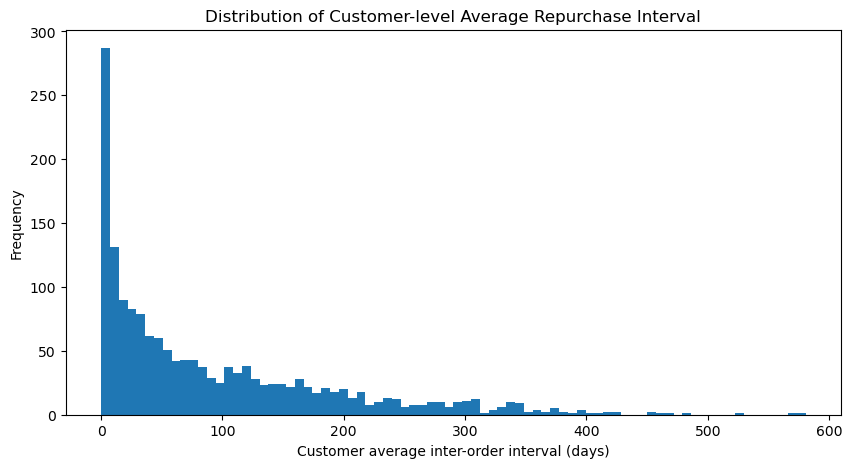

In [67]:
plt.figure(figsize=(10, 5))
plt.hist(customer_avg_gap["avg_gap_days"], bins=80)
plt.xlabel("Customer average inter-order interval (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Customer-level Average Repurchase Interval")
plt.show()

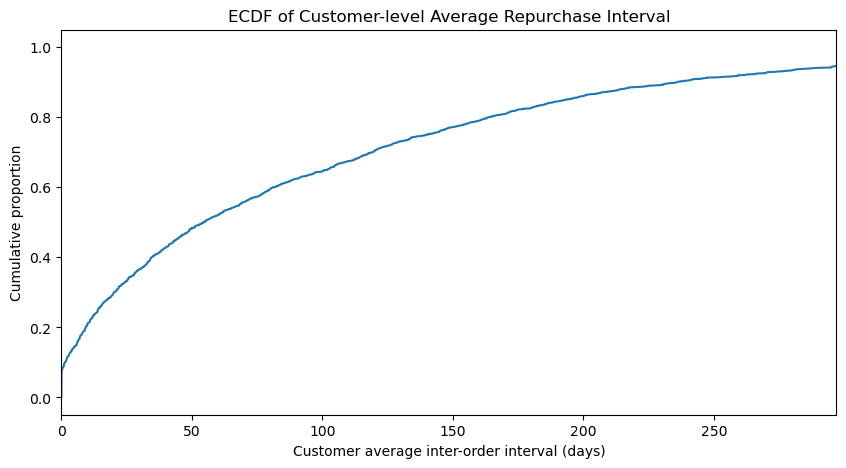

In [68]:
x = np.sort(customer_avg_gap["avg_gap_days"].values)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.xlim(0, p95)
plt.xlabel("Customer average inter-order interval (days)")
plt.ylabel("Cumulative proportion")
plt.title("ECDF of Customer-level Average Repurchase Interval")
plt.show()

In [69]:
customer_avg_gap_summary = pd.DataFrame({
    "metric": [
        "n_customers_with_valid_repurchase",
        "mean_of_avg_gap_days",
        "median_of_avg_gap_days",
        "p25_avg_gap_days",
        "p75_avg_gap_days",
        "p90_avg_gap_days",
        "p95_avg_gap_days",
        "p99_avg_gap_days",
        "avg_gap_le_30d_rate",
        "avg_gap_le_60d_rate",
        "avg_gap_le_90d_rate",
        "avg_gap_le_180d_rate",
    ],
    "value": [
        len(customer_avg_gap),
        customer_avg_gap["avg_gap_days"].mean(),
        customer_avg_gap["avg_gap_days"].median(),
        customer_avg_gap["avg_gap_days"].quantile(0.25),
        customer_avg_gap["avg_gap_days"].quantile(0.75),
        customer_avg_gap["avg_gap_days"].quantile(0.90),
        customer_avg_gap["avg_gap_days"].quantile(0.95),
        customer_avg_gap["avg_gap_days"].quantile(0.99),
        (customer_avg_gap["avg_gap_days"] <= 30).mean(),
        (customer_avg_gap["avg_gap_days"] <= 60).mean(),
        (customer_avg_gap["avg_gap_days"] <= 90).mean(),
        (customer_avg_gap["avg_gap_days"] <= 180).mean(),
    ]
})

customer_avg_gap_summary

,metric,value
0,n_customers_with_valid_repurchase,1636.000000
1,mean_of_avg_gap_days,90.963874
2,median_of_avg_gap_days,54.493750
3,p25_avg_gap_days,13.997222
4,p75_avg_gap_days,139.894792
5,p90_avg_gap_days,235.902083
6,p95_avg_gap_days,298.803819
7,p99_avg_gap_days,394.815347
8,avg_gap_le_30d_rate,0.366137
9,avg_gap_le_60d_rate,0.520171


In [73]:
# 每位回購次數分析 (order_timestamp不同才算回購，若timestamp相同就是同一筆訂單) 
# 定義：同一 customer_unique_id 下，只有 order_purchase_timestamp 不同，才算不同次購買
# 若同一時間戳有多筆 order_id，視為同一次購買事件

df = orders_delivered_base[
    ["customer_unique_id", "order_id", "order_purchase_timestamp"]
].dropna(subset=["customer_unique_id", "order_purchase_timestamp"]).copy()

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"], errors="coerce"
)

df = df.dropna(subset=["order_purchase_timestamp"]).copy()

# 每位顧客的總購買次數（以不同 timestamp 當作一次購買）
customer_purchase_event_cnt = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"]
      .nunique()
      .reset_index(name="total_purchase_events")
)

purchase_count_dist = (
    customer_purchase_event_cnt["total_purchase_events"]
    .value_counts()
    .sort_index()
    .reset_index()
)

purchase_count_dist.columns = ["total_purchase_events", "customer_count"]
purchase_count_dist["customer_rate"] = (
    purchase_count_dist["customer_count"] / purchase_count_dist["customer_count"].sum()
)

purchase_count_dist.head(10)

,total_purchase_events,customer_count,customer_rate
0,1,73684,0.978279
1,2,1508,0.020021
2,3,100,0.001328
3,4,15,0.000199
4,5,6,0.000080
5,6,4,0.000053
6,7,2,0.000027
7,10,1,0.000013


### 4. 驗證每個顧客同一個order_timestamp的訂單是否是不同seller 

In [77]:
# 確認table的order_id 唯一

print("原始資料筆數：", orders_delivered_base.shape[0])
print("原始欄位數：", orders_delivered_base.shape[1])

# 檢查 order_id 是否唯一
dup_order_cnt = orders_delivered_base["order_id"].duplicated().sum()
print("重複的 order_id 筆數：", dup_order_cnt)



原始資料筆數： 77799
原始欄位數： 10
重複的 order_id 筆數： 0


In [78]:
# 找出同一顧客在同一個 timestamp 有兩張以上訂單
orders_delivered_base["order_purchase_timestamp"] = pd.to_datetime(
    orders_delivered_base["order_purchase_timestamp"], errors="coerce"
)

same_ts_orders = (
    orders_delivered_base
    .groupby(["customer_unique_id", "order_purchase_timestamp"])["order_id"]
    .nunique()
    .reset_index(name="n_orders")
    .query("n_orders >= 2")
    .sort_values(["n_orders", "customer_unique_id", "order_purchase_timestamp"], ascending=[False, True, True])
)

print("同一顧客在同一時間點有 2 張以上訂單的組數：", same_ts_orders.shape[0])
same_ts_orders.head(20)

同一顧客在同一時間點有 2 張以上訂單的組數： 644


,customer_unique_id,order_purchase_timestamp,n_orders
1984,06a52782a04f0086d16b9c22d0e29438,2017-05-06 20:11:00,3
11501,25f3cf83109f636d52d288fa4e797111,2018-02-25 21:01:00,3
13988,2e43e031f10de28e557c35ef668f9396,2017-01-26 13:15:00,3
21332,46958f708ade6b6a88b2e5aca1e66de5,2017-08-30 06:22:00,3
27823,5bdb6f56a8fb4272b802f504bb6d1287,2018-02-06 12:16:00,3
31015,66980c3775537536f77b434d74e520f5,2018-03-31 15:08:00,3
32170,6a80a86f478a93a5f4c7ba8db6441a6b,2017-07-26 17:22:00,3
35261,74cb1ad7e6d5674325c1f99b5ea30d82,2017-08-28 20:24:00,3
47318,9cc5a07f169a1606fd347a56683e6ea6,2017-12-13 21:34:00,3
53963,b2bd387fdc3cf05931f0f897d607dc88,2018-02-27 10:55:00,3


In [79]:
# 把這些「同時下單」的訂單明細抓出來看
same_ts_detail = (
    orders_delivered_base
    .merge(
        same_ts_orders[["customer_unique_id", "order_purchase_timestamp"]],
        on=["customer_unique_id", "order_purchase_timestamp"],
        how="inner"
    )
    .sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"])
)

cols_to_show = [
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_id",
    "customer_id",
    "order_status"
]

same_ts_detail[cols_to_show].head(30)

,customer_unique_id,order_purchase_timestamp,order_id,customer_id,order_status
0,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:00,64307ceb91666760cf3ff463618302fd,c0a44bf37d5601228051fc07852f951f,delivered
1,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:00,d61b915b69851aec8a8865f36cfd793e,102fc0966044243157bb81e4ee0a251e,delivered
2,027803eb28cc01fbdf5da72b109fabee,2017-10-17 11:28:00,b1b74907a120888550f895aca299e24b,faba85ebc5cfe2a7bb060d3287493701,delivered
3,027803eb28cc01fbdf5da72b109fabee,2017-10-17 11:28:00,b2fc720676930e0f9f3c1e472e8cddad,5d146b89f4c6cca290b3470a4bb12bcf,delivered
4,02b20b7c813efede140142ac610e36dc,2018-03-19 20:50:00,25ce3a22fa2537206c22c8bef4f9b593,c2dcd18bfda62523dbd2c53ead8b5fe8,delivered
5,02b20b7c813efede140142ac610e36dc,2018-03-19 20:50:00,62ec63f37c8ed14ce3dba43a02721f5e,f227e7071caf55fbd19620ad628aa80e,delivered
6,02fbe4db886eb98774c8ba300d39fa79,2018-02-17 12:23:00,169d7e0fd71d624d306f132acd791cbe,9b75d329d5d07427875e8443ce939770,delivered
7,02fbe4db886eb98774c8ba300d39fa79,2018-02-17 12:23:00,4e93b736e8d687bca088c6ee496437e8,6fd81d719e3abeebb466aabde5dbeb2a,delivered
8,0396c443fdda5498c7e9ed5b34871c5a,2017-05-05 08:44:00,5239a1d5badf5276845d8c71dbeb8fc9,6a5e444906153f324d0252976a4a40a5,delivered
9,0396c443fdda5498c7e9ed5b34871c5a,2017-05-05 08:44:00,c2cd6ce44609af75d061dfab2f67179c,9ae68689eb558472f387541c67ac8592,delivered


In [80]:
#驗證這些同時下單的訂單，是否來自不同 seller
# 同顧客 + 同時間」群組裡：有幾張訂單，有幾個 seller
order_items_path = Path("/Users/kaiping/Desktop/olist_project/data/raw/olist_order_items_dataset.csv")
order_items = pd.read_csv(order_items_path)
order_sellers = order_items[["order_id", "seller_id"]].drop_duplicates()

same_ts_with_sellers = (
    same_ts_detail[["customer_unique_id", "order_purchase_timestamp", "order_id"]]
    .drop_duplicates()
    .merge(order_sellers, on="order_id", how="left")
    .sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id", "seller_id"])
)

same_ts_with_sellers.head(30)

,customer_unique_id,order_purchase_timestamp,order_id,seller_id
0,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:00,64307ceb91666760cf3ff463618302fd,d66c305afaec317ebee552073a674429
1,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:00,d61b915b69851aec8a8865f36cfd793e,4a3ca9315b744ce9f8e9374361493884
2,027803eb28cc01fbdf5da72b109fabee,2017-10-17 11:28:00,b1b74907a120888550f895aca299e24b,cce6ab8d1682639fe45ab70234f1665f
3,027803eb28cc01fbdf5da72b109fabee,2017-10-17 11:28:00,b2fc720676930e0f9f3c1e472e8cddad,5058e8c1e82653974541e83690655b4a
4,02b20b7c813efede140142ac610e36dc,2018-03-19 20:50:00,25ce3a22fa2537206c22c8bef4f9b593,f457c46070d02cadd8a68551231220dd
5,02b20b7c813efede140142ac610e36dc,2018-03-19 20:50:00,62ec63f37c8ed14ce3dba43a02721f5e,6973a06f484aacf400ece213dbf3d946
6,02fbe4db886eb98774c8ba300d39fa79,2018-02-17 12:23:00,169d7e0fd71d624d306f132acd791cbe,0b90b6df587eb83608a64ea8b390cf07
7,02fbe4db886eb98774c8ba300d39fa79,2018-02-17 12:23:00,4e93b736e8d687bca088c6ee496437e8,00fc707aaaad2d31347cf883cd2dfe10
8,0396c443fdda5498c7e9ed5b34871c5a,2017-05-05 08:44:00,5239a1d5badf5276845d8c71dbeb8fc9,d2374cbcbb3ca4ab1086534108cc3ab7
9,0396c443fdda5498c7e9ed5b34871c5a,2017-05-05 08:44:00,c2cd6ce44609af75d061dfab2f67179c,d1c281d3ae149232351cd8c8cc885f0d


In [81]:
same_ts_seller_summary = (
    same_ts_with_sellers
    .groupby(["customer_unique_id", "order_purchase_timestamp"])
    .agg(
        n_orders=("order_id", "nunique"),
        n_sellers=("seller_id", "nunique")
    )
    .reset_index()
    .sort_values(["n_orders", "n_sellers"], ascending=[False, False])
)

same_ts_seller_summary.head(20)

,customer_unique_id,order_purchase_timestamp,n_orders,n_sellers
276,6a80a86f478a93a5f4c7ba8db6441a6b,2017-07-26 17:22:00,3,4
103,2e43e031f10de28e557c35ef668f9396,2017-01-26 13:15:00,3,3
302,74cb1ad7e6d5674325c1f99b5ea30d82,2017-08-28 20:24:00,3,3
540,d7624d219b6ffad980e91412174db310,2017-04-05 17:58:00,3,3
214,5bdb6f56a8fb4272b802f504bb6d1287,2018-02-06 12:16:00,3,2
452,b2bd387fdc3cf05931f0f897d607dc88,2018-02-27 10:55:00,3,2
459,b64ebaf3d11b7209fe566364cc359a51,2017-07-17 22:44:00,3,2
533,d3882d7abd0c66064d740d7ed04dd1ef,2018-02-14 11:52:00,3,2
591,e78838df9c44e102b6ac84cc5eea7d5c,2017-02-07 22:52:00,3,2
7,06a52782a04f0086d16b9c22d0e29438,2017-05-06 20:11:00,3,1


In [82]:
#同一個顧客在同一時間點的多筆訂單，是否對應不同 seller？
same_ts_seller_summary["different_seller_flag"] = same_ts_seller_summary["n_sellers"] > 1

same_ts_seller_summary["different_seller_flag"].value_counts(dropna=False)

different_seller_flag
True     456
False    188
Name: count, dtype: int64

In [83]:
same_ts_seller_summary["different_seller_flag"].mean()

np.float64(0.7080745341614907)

在同一顧客、同一購買時間點出現多張訂單的群組中，約 70.8% 涉及不同 seller，顯示同一購買事件被拆分為多張訂單，且此現象與多 seller 購買高度相關。因此，在回購與二購分析中，若直接以 order_id 計算購買次數，可能高估顧客的實際回購行為。基於此，本研究將同一顧客於相同 order_purchase_timestamp 發生之多筆訂單，視為同一次購買事件。

### 5. cohort retention 分析